In [397]:
# import and setup a model
import torch
from ultralytics import YOLO
import numpy as np

yolo = YOLO("yolov5nu.pt")
net = yolo.model

In [398]:
# # Here are all functions used in the runtime - they appered as they in the __init__
net

DetectionModel(
  (model): Sequential(
    (0): Conv(
      (conv): Conv2d(3, 16, kernel_size=(6, 6), stride=(2, 2), padding=(2, 2), bias=False)
      (bn): BatchNorm2d(16, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
      (act): SiLU(inplace=True)
    )
    (1): Conv(
      (conv): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
      (act): SiLU(inplace=True)
    )
    (2): C3(
      (cv1): Conv(
        (conv): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn): BatchNorm2d(16, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (cv2): Conv(
        (conv): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn): BatchNorm2d(16, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
     

In [399]:
# sniff a runtime
execution = []
no_dup_execution = []

# to remove duplicates
seen = set()

def add_hook(module, name):
    def hook(module, input, output):
        execution.append(name)
    return hook

for name, m in net.named_modules():
    if isinstance(m, (torch.nn.Conv2d, torch.nn.BatchNorm2d, torch.nn.SiLU,
                      torch.nn.MaxPool2d, torch.nn.Upsample)):
        m.register_forward_hook(add_hook(m, name))

# a forward pass
x = torch.randn(1, 3, 640, 640)
net(x)

for layer in execution:
    if layer not in seen:
        no_dup_execution.append(layer)
        seen.add(layer)



print(execution)
duplicates = [x for x in execution if execution.count(x) > 1]
print(any(execution.count(x) > 1 for x in execution))
print(duplicates)
print(no_dup_execution)
len(no_dup_execution)


## We cant really build map using this as python may reuse functions and some layers are not defined using function

['model.0.conv', 'model.0.bn', 'model.0.act', 'model.1.conv', 'model.1.bn', 'model.0.act', 'model.2.cv1.conv', 'model.2.cv1.bn', 'model.0.act', 'model.2.m.0.cv1.conv', 'model.2.m.0.cv1.bn', 'model.0.act', 'model.2.m.0.cv2.conv', 'model.2.m.0.cv2.bn', 'model.0.act', 'model.2.cv2.conv', 'model.2.cv2.bn', 'model.0.act', 'model.2.cv3.conv', 'model.2.cv3.bn', 'model.0.act', 'model.3.conv', 'model.3.bn', 'model.0.act', 'model.4.cv1.conv', 'model.4.cv1.bn', 'model.0.act', 'model.4.m.0.cv1.conv', 'model.4.m.0.cv1.bn', 'model.0.act', 'model.4.m.0.cv2.conv', 'model.4.m.0.cv2.bn', 'model.0.act', 'model.4.m.1.cv1.conv', 'model.4.m.1.cv1.bn', 'model.0.act', 'model.4.m.1.cv2.conv', 'model.4.m.1.cv2.bn', 'model.0.act', 'model.4.cv2.conv', 'model.4.cv2.bn', 'model.0.act', 'model.4.cv3.conv', 'model.4.cv3.bn', 'model.0.act', 'model.5.conv', 'model.5.bn', 'model.0.act', 'model.6.cv1.conv', 'model.6.cv1.bn', 'model.0.act', 'model.6.m.0.cv1.conv', 'model.6.m.0.cv1.bn', 'model.0.act', 'model.6.m.0.cv2.conv

149

In [400]:
# layer_nums_back_c3 = use net
layer_nums_c3 = []
layer_nums_sppf = []

for i, layer in enumerate(net.model):
    name = layer.__class__.__name__.lower()
    if 'c3' in name:
        layer_nums_c3.append(i)
    if 'sppf' in name:
        layer_nums_sppf.append(i)

layer_nums_back_c3 = layer_nums_c3[:4]

print("C3 layers:", layer_nums_c3)
print("C3 back layers:", layer_nums_back_c3)
print("SPPF layers:", layer_nums_sppf)

C3 layers: [2, 4, 6, 8, 13, 17, 20, 23]
C3 back layers: [2, 4, 6, 8]
SPPF layers: [9]


In [401]:
def flatten_atomic(module, prefix=""):
    atomic_layers = []
    for name, sub in module.named_children():
        full_name = f"{prefix}.{name}" if prefix else name
        if list(sub.children()):
            atomic_layers.extend(flatten_atomic(sub, prefix=full_name))
        else:
            atomic_layers.append({"full_name": full_name, "model": sub})
    return atomic_layers

atomic_layers_unordered_incomplete = flatten_atomic(net.model)
atomic_layers_unordered_incomplete

[{'full_name': '0.conv',
  'model': Conv2d(3, 16, kernel_size=(6, 6), stride=(2, 2), padding=(2, 2), bias=False)},
 {'full_name': '0.bn',
  'model': BatchNorm2d(16, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)},
 {'full_name': '0.act', 'model': SiLU(inplace=True)},
 {'full_name': '1.conv',
  'model': Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)},
 {'full_name': '1.bn',
  'model': BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)},
 {'full_name': '1.act', 'model': SiLU(inplace=True)},
 {'full_name': '2.cv1.conv',
  'model': Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)},
 {'full_name': '2.cv1.bn',
  'model': BatchNorm2d(16, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)},
 {'full_name': '2.cv1.act', 'model': SiLU(inplace=True)},
 {'full_name': '2.cv2.conv',
  'model': Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)},
 {'full_name': '2.cv2.bn',
  'model': Ba

In [402]:
# reorder C3 block as we heard in sniffing
# policy: cv1 -> cv2 -> cv3 -> m to cv1 -> m -> cv2 -> cv3
def reorder_c3_blocks(layers):
    reordered = []
    c3_buffer = []
    for layer in layers:
        name = layer['full_name']
        ln = int(name.split('.')[0])
        if any(x in name for x in ['.cv1.', '.cv2.', '.cv3.', '.m.']) and ln in layer_nums_c3:
            c3_buffer.append(layer)
        else:
            if c3_buffer:
                cv1 = [l for l in c3_buffer if '.cv1.' in l['full_name'] and '.m.' not in l['full_name']]
                cv2 = [l for l in c3_buffer if '.cv2.' in l['full_name'] and '.m.' not in l['full_name']]
                cv3 = [l for l in c3_buffer if '.cv3.' in l['full_name'] and '.m.' not in l['full_name']]
                m   = [l for l in c3_buffer if '.m.' in l['full_name']]
                reordered.extend(cv1 + m + cv2 + cv3)
                c3_buffer = []
            reordered.append(layer)
    if c3_buffer:
        cv1 = [l for l in c3_buffer if '.cv1.' in l['full_name'] and '.m.' not in l['full_name']]
        cv2 = [l for l in c3_buffer if '.cv2.' in l['full_name'] and '.m.' not in l['full_name']]
        cv3 = [l for l in c3_buffer if '.cv3.' in l['full_name'] and '.m.' not in l['full_name']]
        m   = [l for l in c3_buffer if '.m.' in l['full_name']]
        reordered.extend(cv1 + m + cv2 + cv3)
    return reordered

atomic_layer_ordered = reorder_c3_blocks(atomic_layers_unordered_incomplete)
atomic_layer_ordered


# reorder SPPF block as we heard in sniffing
# policy: cv1 -> cv2 -> m to cv1 -> m -> cv2
def reorder_sppf_blocks(layers):
    reordered = []
    sppf_buffer = []
    for layer in layers:
        name = layer['full_name']
        ln = int(name.split('.')[0])
        if any(x in name for x in ['.cv1', '.cv2', '.m']) and ln in layer_nums_sppf:
            sppf_buffer.append(layer)
        else:
            if sppf_buffer:
                cv1 = [l for l in sppf_buffer if '.cv1' in l['full_name'] and '.m' not in l['full_name']]
                cv2 = [l for l in sppf_buffer if '.cv2' in l['full_name'] and '.m' not in l['full_name']]
                m   = [l for l in sppf_buffer if '.m' in l['full_name']]
                reordered.extend(cv1 + m + cv2)
                sppf_buffer = []
            reordered.append(layer)
    if sppf_buffer:
        cv1 = [l for l in sppf_buffer if '.cv1' in l['full_name'] and '.m' not in l['full_name']]
        cv2 = [l for l in sppf_buffer if '.cv.' in l['full_name'] and '.m' not in l['full_name']]
        m   = [l for l in sppf_buffer if '.m.' in l['full_name']]
        reordered.extend(cv1 + m + cv2)
    return reordered

atomic_layer_ordered = reorder_sppf_blocks(atomic_layer_ordered)
atomic_layer_ordered

[{'full_name': '0.conv',
  'model': Conv2d(3, 16, kernel_size=(6, 6), stride=(2, 2), padding=(2, 2), bias=False)},
 {'full_name': '0.bn',
  'model': BatchNorm2d(16, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)},
 {'full_name': '0.act', 'model': SiLU(inplace=True)},
 {'full_name': '1.conv',
  'model': Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)},
 {'full_name': '1.bn',
  'model': BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)},
 {'full_name': '1.act', 'model': SiLU(inplace=True)},
 {'full_name': '2.cv1.conv',
  'model': Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)},
 {'full_name': '2.cv1.bn',
  'model': BatchNorm2d(16, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)},
 {'full_name': '2.cv1.act', 'model': SiLU(inplace=True)},
 {'full_name': '2.m.0.cv1.conv',
  'model': Conv2d(16, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)},
 {'full_name': '2.m.0.cv1.bn',
  'mo

In [403]:
def debug_compare(list1, list2):
    if len(list1) != len(list2):
        print(f"Warning: Lists have different lengths: {len(list1)} vs {len(list2)}")
    for i, (a, b) in enumerate(zip(list1, list2)):
        if a == b:
            print(f"\nIndex {i}: \nmatches: {a}")
        else:
            print(f"\nIndex {i}:\nelem1: {a}, \nelem2: {b}")

debug_compare(atomic_layers_unordered_incomplete, atomic_layer_ordered)


Index 0: 
matches: {'full_name': '0.conv', 'model': Conv2d(3, 16, kernel_size=(6, 6), stride=(2, 2), padding=(2, 2), bias=False)}

Index 1: 
matches: {'full_name': '0.bn', 'model': BatchNorm2d(16, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)}

Index 2: 
matches: {'full_name': '0.act', 'model': SiLU(inplace=True)}

Index 3: 
matches: {'full_name': '1.conv', 'model': Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)}

Index 4: 
matches: {'full_name': '1.bn', 'model': BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)}

Index 5: 
matches: {'full_name': '1.act', 'model': SiLU(inplace=True)}

Index 6: 
matches: {'full_name': '2.cv1.conv', 'model': Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)}

Index 7: 
matches: {'full_name': '2.cv1.bn', 'model': BatchNorm2d(16, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)}

Index 8: 
matches: {'full_name': '2.cv1.act', 'model': SiLU(inplace=T

In [404]:
# add missing concat, res_add
# policy:
# add a {'full_name': 'x', 'model': Concat()}, // literary an x letter 
# 1. just before cv3.conv in c3 blocks
# 2. just before cv2.conv in sppf blocks
# add a {'full_name': 'x', 'model': "ResAdd()"}, // literary an x letter
# just before previously add Concat if in c3_back


from copy import deepcopy
from torch import nn

atomic_layers_ordered_completed = deepcopy(atomic_layer_ordered)
i = 0
while i < len(atomic_layers_ordered_completed):
    layer = atomic_layers_ordered_completed[i]
    name = layer['full_name'].lower()
    ln = int(name.split('.')[0])
    is_c3_cv3 = ('.cv3.conv' in name and ln in layer_nums_c3)
    is_sppf_cv2 = ('.cv2.conv' in name and ln in layer_nums_sppf)
    if (is_c3_cv3 or is_sppf_cv2) and ('.m' not in name):
        if is_c3_cv3 and ln in layer_nums_back_c3:
            atomic_layers_ordered_completed.insert(i, {'full_name': 'x', 'model': "resadd"})
            i += 1
        atomic_layers_ordered_completed.insert(i, {'full_name': 'x', 'model': "concat"})
        i += 1
    i += 1

atomic_layers_ordered_completed

[{'full_name': '0.conv',
  'model': Conv2d(3, 16, kernel_size=(6, 6), stride=(2, 2), padding=(2, 2), bias=False)},
 {'full_name': '0.bn',
  'model': BatchNorm2d(16, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)},
 {'full_name': '0.act', 'model': SiLU(inplace=True)},
 {'full_name': '1.conv',
  'model': Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)},
 {'full_name': '1.bn',
  'model': BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)},
 {'full_name': '1.act', 'model': SiLU(inplace=True)},
 {'full_name': '2.cv1.conv',
  'model': Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)},
 {'full_name': '2.cv1.bn',
  'model': BatchNorm2d(16, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)},
 {'full_name': '2.cv1.act', 'model': SiLU(inplace=True)},
 {'full_name': '2.m.0.cv1.conv',
  'model': Conv2d(16, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)},
 {'full_name': '2.m.0.cv1.bn',
  'mo

In [405]:
debug_compare(atomic_layers_unordered_incomplete, atomic_layers_ordered_completed)


Index 0:
elem1: {'full_name': '0.conv', 'model': Conv2d(3, 16, kernel_size=(6, 6), stride=(2, 2), padding=(2, 2), bias=False)}, 
elem2: {'full_name': '0.conv', 'model': Conv2d(3, 16, kernel_size=(6, 6), stride=(2, 2), padding=(2, 2), bias=False)}

Index 1:
elem1: {'full_name': '0.bn', 'model': BatchNorm2d(16, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)}, 
elem2: {'full_name': '0.bn', 'model': BatchNorm2d(16, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)}

Index 2:
elem1: {'full_name': '0.act', 'model': SiLU(inplace=True)}, 
elem2: {'full_name': '0.act', 'model': SiLU(inplace=True)}

Index 3:
elem1: {'full_name': '1.conv', 'model': Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)}, 
elem2: {'full_name': '1.conv', 'model': Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)}

Index 4:
elem1: {'full_name': '1.bn', 'model': BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_sta

In [406]:
atomic_layers = atomic_layers_unordered_incomplete
atomic_layers_ordered_completed

[{'full_name': '0.conv',
  'model': Conv2d(3, 16, kernel_size=(6, 6), stride=(2, 2), padding=(2, 2), bias=False)},
 {'full_name': '0.bn',
  'model': BatchNorm2d(16, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)},
 {'full_name': '0.act', 'model': SiLU(inplace=True)},
 {'full_name': '1.conv',
  'model': Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)},
 {'full_name': '1.bn',
  'model': BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)},
 {'full_name': '1.act', 'model': SiLU(inplace=True)},
 {'full_name': '2.cv1.conv',
  'model': Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)},
 {'full_name': '2.cv1.bn',
  'model': BatchNorm2d(16, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)},
 {'full_name': '2.cv1.act', 'model': SiLU(inplace=True)},
 {'full_name': '2.m.0.cv1.conv',
  'model': Conv2d(16, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)},
 {'full_name': '2.m.0.cv1.bn',
  'mo

In [407]:
from typing import List, Dict

def generate_config(layers: List[Dict]) -> List[List[int]]:
    config=[]
    for layer in layers:
        inner=[]
        model=layer['model']
        op_type='unknown'
        if isinstance(model,str):
            op_type=model.lower()
        else:
            cls_name=model.__class__.__name__.lower()
            if 'conv' in cls_name:op_type='conv'
            elif 'batchnorm' in cls_name:op_type='bn'
            elif 'relu' in cls_name or 'silu' in cls_name:op_type='activation'
            elif 'maxpool' in cls_name:op_type='pool'
            elif 'upsample' in cls_name:op_type='upsample'
            elif 'concat' in cls_name:op_type='concat'
            elif 'resadd' in cls_name:op_type='resadd'
            elif 'c3' in cls_name:op_type='c3'
            elif 'sppf' in cls_name:op_type='sppf'
            elif 'detect' in cls_name:op_type='detect'
        inner.append(op_type)
        if op_type=='conv':
            in_ch=model.in_channels
            out_ch=model.out_channels
            k_h,k_w=model.kernel_size if isinstance(model.kernel_size,tuple) else (model.kernel_size,model.kernel_size)
            s_h,s_w=model.stride if isinstance(model.stride,tuple) else (model.stride,model.stride)
            p_h,p_w=model.padding if isinstance(model.padding,tuple) else (model.padding,model.padding)
            bias=model.bias is not None
            inner.extend([in_ch,out_ch,k_h,k_w,s_h,s_w,p_h,p_w,bias])
        elif op_type=='bn':
            num_feat=model.num_features
            eps=model.eps
            momentum=model.momentum
            affine=model.affine
            track_stats=model.track_running_stats
            inner.extend([num_feat,eps,momentum,affine,track_stats])
        elif op_type=='activation':
            inplace=getattr(model,'inplace',False)
            inner.append(inplace)
        elif op_type=='pool':
            k_h,k_w=model.kernel_size if isinstance(model.kernel_size,tuple) else (model.kernel_size,model.kernel_size)
            s_h,s_w=model.stride if isinstance(model.stride,tuple) else (model.stride,model.stride)
            p_h,p_w=model.padding if isinstance(model.padding,tuple) else (model.padding,model.padding)
            d_h,d_w=model.dilation if isinstance(model.dilation,tuple) else (model.dilation,model.dilation)
            ceil_mode=model.ceil_mode
            inner.extend([k_h,k_w,s_h,s_w,p_h,p_w,d_h,d_w,ceil_mode])
        elif op_type=='upsample':
            scale_h,scale_w=model.scale_factor if isinstance(model.scale_factor,tuple) else (model.scale_factor,model.scale_factor)
            mode=model.mode
            inner.extend([scale_h,scale_w,mode])
        config.append(inner)
    return config

config=generate_config(atomic_layers_ordered_completed)

In [408]:
# conv:                         [op_type, in_ch, out_ch, k_h, k_w, s_h, s_w, p_h, p_w, bias]
# bn:                           [op_type, num_features, eps, momentum, affine, track_running_stats]
# activation:                   [op_type, inplace]
# pool:                         [op_type, k_h, k_w, s_h, s_w, p_h, p_w, d_h, d_w, ceil_mode]
# upsample:                     [op_type, scale_h, scale_w, mode]
# concat/resadd/c3/sppf/detect: [op_type] (no params)
config

[['conv', 3, 16, 6, 6, 2, 2, 2, 2, False],
 ['bn', 16, 0.001, 0.03, True, True],
 ['activation', True],
 ['conv', 16, 32, 3, 3, 2, 2, 1, 1, False],
 ['bn', 32, 0.001, 0.03, True, True],
 ['activation', True],
 ['conv', 32, 16, 1, 1, 1, 1, 0, 0, False],
 ['bn', 16, 0.001, 0.03, True, True],
 ['activation', True],
 ['conv', 16, 16, 1, 1, 1, 1, 0, 0, False],
 ['bn', 16, 0.001, 0.03, True, True],
 ['activation', True],
 ['conv', 16, 16, 3, 3, 1, 1, 1, 1, False],
 ['bn', 16, 0.001, 0.03, True, True],
 ['activation', True],
 ['conv', 32, 16, 1, 1, 1, 1, 0, 0, False],
 ['bn', 16, 0.001, 0.03, True, True],
 ['activation', True],
 ['resadd'],
 ['concat'],
 ['conv', 32, 32, 1, 1, 1, 1, 0, 0, False],
 ['bn', 32, 0.001, 0.03, True, True],
 ['activation', True],
 ['conv', 32, 64, 3, 3, 2, 2, 1, 1, False],
 ['bn', 64, 0.001, 0.03, True, True],
 ['activation', True],
 ['conv', 64, 32, 1, 1, 1, 1, 0, 0, False],
 ['bn', 32, 0.001, 0.03, True, True],
 ['activation', True],
 ['conv', 32, 32, 1, 1, 1, 1, 

In [409]:
# make weights list
weights=[]

state_dict = net.state_dict()
weights_list_unordered_incomplete = [{ "name": k, "weight": v.cpu()} for k, v in state_dict.items()]

name_to_weight={w["name"]:w["weight"] for w in weights_list_unordered_incomplete}
for layer in atomic_layers_ordered_completed:
    fname=layer["full_name"]
    inner=[]
    if fname!="x":
        prefix="model."+fname
        for k,v in name_to_weight.items():
            if k.startswith(prefix):
                inner.append(v)
    weights.append(inner)

In [410]:
weights

for i,layer in enumerate(weights):
    print(f"layer {i}:")
    if not layer:
        print("  []")
    else:
        for j,t in enumerate(layer):
            print(f"  tensor {j} shape={tuple(t.shape)}")

layer 0:
  tensor 0 shape=(16, 3, 6, 6)
layer 1:
  tensor 0 shape=(16,)
  tensor 1 shape=(16,)
  tensor 2 shape=(16,)
  tensor 3 shape=(16,)
  tensor 4 shape=()
layer 2:
  []
layer 3:
  tensor 0 shape=(32, 16, 3, 3)
layer 4:
  tensor 0 shape=(32,)
  tensor 1 shape=(32,)
  tensor 2 shape=(32,)
  tensor 3 shape=(32,)
  tensor 4 shape=()
layer 5:
  []
layer 6:
  tensor 0 shape=(16, 32, 1, 1)
layer 7:
  tensor 0 shape=(16,)
  tensor 1 shape=(16,)
  tensor 2 shape=(16,)
  tensor 3 shape=(16,)
  tensor 4 shape=()
layer 8:
  []
layer 9:
  tensor 0 shape=(16, 16, 1, 1)
layer 10:
  tensor 0 shape=(16,)
  tensor 1 shape=(16,)
  tensor 2 shape=(16,)
  tensor 3 shape=(16,)
  tensor 4 shape=()
layer 11:
  []
layer 12:
  tensor 0 shape=(16, 16, 3, 3)
layer 13:
  tensor 0 shape=(16,)
  tensor 1 shape=(16,)
  tensor 2 shape=(16,)
  tensor 3 shape=(16,)
  tensor 4 shape=()
layer 14:
  []
layer 15:
  tensor 0 shape=(16, 32, 1, 1)
layer 16:
  tensor 0 shape=(16,)
  tensor 1 shape=(16,)
  tensor 2 shape=(

In [411]:
from graphviz import Digraph
def visualize_graph(graph, raw):
    g = Digraph("AtomicDAG", format="pdf")
    g.attr(rankdir="TB", nodesep="0.6", ranksep="0.9")
    g.attr(
        "node",
        shape="box",
        fontsize="14",
        fontname="Helvetica",
        style="rounded"
    )
    for i, layer in enumerate(raw):
        name = layer["full_name"]
        label = f"{i}\n{name}"
        g.node(str(i), label)
    for tar, srcs in enumerate(graph):
        for src in srcs:
            if src >= 0:
                g.edge(str(src), str(tar))

    return g
# graphviz_graph = visualize_graph(graph, atomic_layers_ordered_completed)
# graphviz_graph.render("model/atomic_dag", view=True, cleanup=True)

In [412]:
# creating the DAG

# part I: by default connect to the previous layer
graph=[[idx-1] for idx, _ in enumerate(atomic_layers_ordered_completed)]

In [413]:
def print_list(*lists):
    for i,items in enumerate(zip(*lists)):print("idx", i,":\n",*items)
# print_list(graph)

graphviz_graph = visualize_graph(graph, atomic_layers_ordered_completed)
# graphviz_graph

In [414]:
# part II: handle special cases in c3 and sppf blocks
# use atomic_layers_ordered_completed and layer_nums_c3, layer_nums_sppf, layer_nums_back_c3

# if in layer_nums_back_c3
# 1. copy c1 = first_cnv_in
# 2. copy c2 = first_m.cnv_in
# 3. copy c3 = second_cnv_in and then second_cnv_in = c1
# 4. copy c4 = resadd_in and then resadd_in = c2, c3 and concat_in.append(c4)

# if in not in layer_nums_back_c3 but in layer_nums_c3
# 1. copy c1 = first_cnv_in
# 2. copy c2 = second_cnv_in then second_cnv_in = c1
# 4. concat_in.append(c2)

# if in layer_nums_sppf
# 1. copy c1 = .m_in
# 2. concat_in.append(c1)

def node_name(idx):
    if 0 <= idx < len(atomic_layers_ordered_completed):
        return atomic_layers_ordered_completed[idx]["full_name"]
    return f"<out:{idx}>"

num_bottlenecks = {2: 1, 4: 2, 6: 3, 8: 1}
for i,layer in enumerate(atomic_layers_ordered_completed):
    name=layer["full_name"]
    ln = int(name.split('.')[0]) if name.split('.')[0] != 'x' else -10e6
    if ln in layer_nums_back_c3:
        if (name.split('.')[1:]==["cv1", "conv"]):
            c1=graph[i][0]
            c2=graph[i+3][0]
            c3=graph[i+3+6*num_bottlenecks[ln]][0]
            c4=graph[i+3+6*num_bottlenecks[ln]+3][0]
            print(f"Handling c3 back block at layer {i} ({name})")
            print("cv1:", node_name(c1), "m:", node_name(c2), "cv2:", node_name(c3), "res:", node_name(c4))
            graph[i+3+6*num_bottlenecks[ln]]=[c1]
            graph[i+3+6*num_bottlenecks[ln]+3]=[c2,c3]
            graph[i+3+6*num_bottlenecks[ln]+3+1].append(c4)

    elif ln in layer_nums_c3:
        if (name.split('.')[1:]==["cv1", "conv"]):
            c1=graph[i][0]
            c2=graph[i+9][0]
            graph[i+9]=[c1]
            graph[i+12].append(c2)

    elif ln in layer_nums_sppf:
        if (name.split('.')[1]=="m"):
            c1=graph[i][0]
            graph[i+1].append(c1)

# print_list(graph)

Handling c3 back block at layer 6 (2.cv1.conv)
cv1: 1.act m: 2.cv1.act cv2: 2.m.0.cv2.act res: 2.cv2.act
Handling c3 back block at layer 26 (4.cv1.conv)
cv1: 3.act m: 4.cv1.act cv2: 4.m.1.cv2.act res: 4.cv2.act
Handling c3 back block at layer 52 (6.cv1.conv)
cv1: 5.act m: 6.cv1.act cv2: 6.m.2.cv2.act res: 6.cv2.act
Handling c3 back block at layer 84 (8.cv1.conv)
cv1: 7.act m: 8.cv1.act cv2: 8.m.0.cv2.act res: 8.cv2.act


In [415]:
# visualize_graph(graph, atomic_layers_ordered_completed)

In [416]:
# part III: handle the special case the head


In [417]:
# part IV: see what the pytorch says about edges
layer_graph = {}
for i, m in enumerate(net.model):
    if hasattr(m, 'f'):
        if isinstance(m.f, int):
            from_layers = [m.f]
        else:
            from_layers = m.f if len(m.f) > 0 else [-1]
    else:
        from_layers = [-1]
    layer_graph[i] = from_layers


# this helper do this when to it we pass the src, dest in torch layer number it connects
def connect(src, tar, graph, raw):
    # interate through the raw = atomic_layers_ordered_completed once while doing so find 
    # 1. c1 = the last idx with the src
    # 2. c2 = the very first with the tar
    # then in the graph add the idx 1 to the graph[c2].append(c1)
    last_src = None
    first_tar = None
    for i, layer in enumerate(raw):
        name = layer["full_name"]
        ln = int(name.split('.')[0]) if name.split('.')[0] != 'x' else None
        # find last src
        if ln == src:
            last_src = i
        # find first tar
        if first_tar is None and ln == tar:
            first_tar = i
    if last_src is None:
        raise ValueError(f"Source layer {src} not found")
    if first_tar is None:
        raise ValueError(f"Target layer {tar} not found")
    graph[first_tar].append(last_src)
    return graph

def apply_layer_graph(layer_graph, graph, raw, except_tars = None):
    for tar in layer_graph.keys():
        if tar not in except_tars:
            srcs = layer_graph[tar]
            for src in srcs:
                if src < 0:
                    continue
                graph = connect(src, tar, graph, raw)
    return graph

# part III: handle the concats in the neck
apply_layer_graph(layer_graph, graph, atomic_layers_ordered_completed, except_tars=[24]);

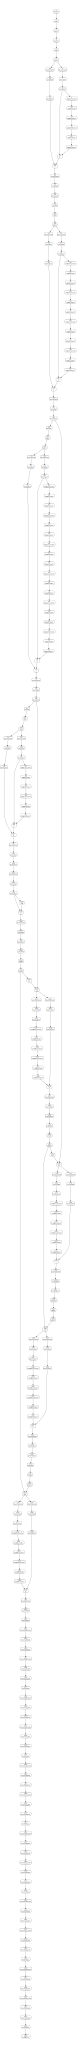

In [ ]:
visualize_graph(graph, atomic_layers_ordered_completed).render("model/atomic_dag", view=True, cleanup=True)